# ***1. Carga de las librerías***

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import sys
import os

sys.path.append(os.path.abspath(".."))

# ***2. Carga del dataset preparado***

In [4]:
# Cargo el parquet para mantener los tipos de las columnas que se parsearon
df_pois = pd.read_parquet('../data/pois_barcelona_procesados.parquet')
df_pois.head(3)

,id,name,category,subcategory,latitude,longitude,city,description,rating,match_confidence,...,opening_hours_source,has_opening_hours,is_24_7,is_likely_open,has_match_confidence,score,has_valid_source,visit_duration,tags,tags_str
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,Barcelona,national library,4.2,0.930000,...,OSM,True,False,True,True,3.21900,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,Barcelona,neighborhood,4.1,0.503766,...,None,False,False,False,False,2.56796,False,60,"[culture, indoor]",culture|indoor
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,Barcelona,masia,4.1,0.650000,...,OSM,True,False,True,True,3.06500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor


In [5]:
# Comprobamos los tipos y las dimensiones del dataset
print(df_pois.shape)
df_pois.dtypes

(775, 21)


id                         int64
name                      object
category                category
subcategory             category
latitude                 float64
longitude                float64
city                      object
description               object
rating                   float64
match_confidence         float64
opening_hours             object
opening_hours_source      object
has_opening_hours           bool
is_24_7                     bool
is_likely_open              bool
has_match_confidence        bool
score                    float64
has_valid_source            bool
visit_duration             int64
tags                      object
tags_str                  object
dtype: object

In [6]:
# Comprobamos que los nombres de las columnas estén bien
df_pois.columns.to_list()

['id',
 'name',
 'category',
 'subcategory',
 'latitude',
 'longitude',
 'city',
 'description',
 'rating',
 'match_confidence',
 'opening_hours',
 'opening_hours_source',
 'has_opening_hours',
 'is_24_7',
 'is_likely_open',
 'has_match_confidence',
 'score',
 'has_valid_source',
 'visit_duration',
 'tags',
 'tags_str']

# ***3. Análisis estadístico de las columnas numéricas***

In [7]:
df_pois.describe()

,id,latitude,longitude,rating,match_confidence,score,visit_duration
count,775.000000,774.000000,774.000000,775.000000,775.000000,775.000000,775.000000
mean,155274.060645,41.394579,2.163020,4.337032,0.503766,2.953729,53.690323
std,163853.238230,0.019954,0.021307,0.354424,0.151039,0.316948,36.461648
min,3.000000,41.346300,2.057790,2.800000,0.060000,1.794460,10.000000
25%,6023.500000,41.382225,2.149145,4.200000,0.435000,2.746460,20.000000
50%,12824.000000,41.388350,2.166690,4.400000,0.503766,2.924960,60.000000
75%,335555.000000,41.403575,2.176598,4.600000,0.503766,3.206000,60.000000
max,336511.000000,41.453600,2.221330,4.900000,1.000000,3.709000,120.000000


### ***📊 Análisis estadístico de las variables numéricas***

A partir del resumen estadístico (`describe()`), se pueden extraer varias conclusiones relevantes sobre la distribución de las variables numéricas del dataset:

#### 📍 Variables geográficas (`latitude`, `longitude`)
- Los valores de latitud y longitud presentan una **baja desviación estándar**, lo que indica que todos los puntos de interés están correctamente concentrados en la ciudad de Barcelona.
- No se observan valores extremos o incoherentes, lo que confirma que el proceso de limpieza geográfica ha sido efectivo.

#### ⭐ `rating`
- La media se sitúa en torno a **4.33**, con una mediana de **4.4**, lo que indica que la mayoría de los POIs tienen valoraciones altas.
- La distribución está ligeramente sesgada hacia valores elevados, lo cual es habitual en este tipo de plataformas (tendencia a valoraciones positivas).
- El valor mínimo (~2.8) representa posibles outliers o POIs con menor calidad percibida.

#### 🎯 `match_confidence`
- Presenta una media cercana a **0.50**, lo que indica un nivel de confianza medio en la correspondencia de los datos enriquecidos.
- La mediana coincide con la media, lo que sugiere una distribución relativamente equilibrada.
- Se observan valores desde **0.06 hasta 1.0**, lo que refleja una alta variabilidad en la calidad de los datos.

#### 🧮 `score`
- El `score` presenta una media en torno a **2.95**, integrando tanto la valoración como la calidad del dato.
- La dispersión es moderada, lo que indica que el sistema de scoring está diferenciando correctamente entre POIs.
- Los valores más altos (~3.7) corresponden a POIs con alta valoración y alta confianza.

#### ⏱️ `visit_duration`
- La duración media de visita es de aproximadamente **54 minutos**, con una mediana de **60 minutos**, lo que sugiere que la mayoría de los POIs requieren alrededor de una hora de visita.
- Se observan valores mínimos de **10 minutos** (visitas rápidas) y máximos de **120 minutos** (experiencias más completas como museos).
- Esta variable será clave para la generación de rutas optimizadas en función del tiempo disponible del usuario.

---

### 🧠 Conclusión

El análisis estadístico confirma que el dataset presenta una **distribución coherente y realista**, sin anomalías significativas tras el proceso de limpieza. Las variables numéricas están bien definidas y serán fundamentales en la construcción del sistema de recomendación, especialmente en aspectos como la calidad del POI, la fiabilidad de los datos y la planificación temporal de las rutas.

---

# ***4. Análisis y visualizaciones***

## ***4.1 Distribución del rating***

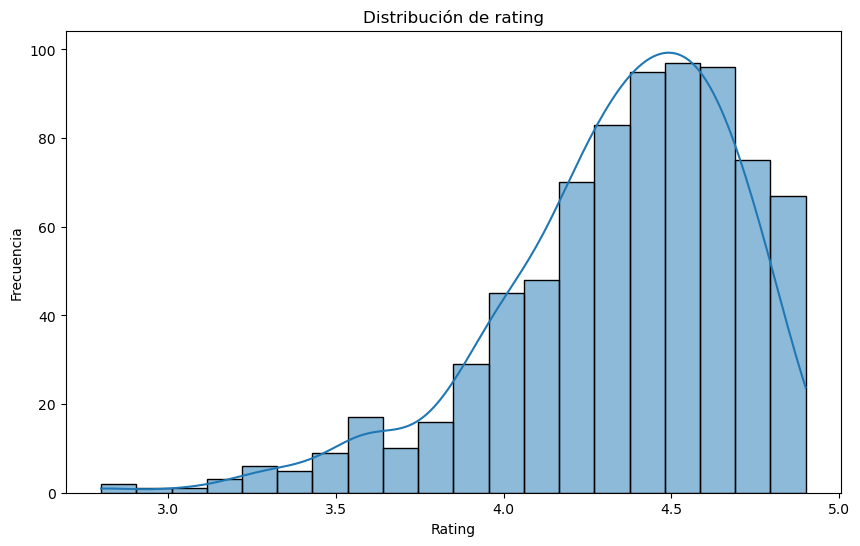

In [8]:
#Histograma para ver la distribución del rating
plt.figure(figsize=(10,6))
sns.histplot(df_pois["rating"], bins=20,kde=True)
plt.title("Distribución de rating")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

### 📊 Conclusión - Distribución del rating

El análisis de la distribución de los *ratings* en los POIs evidencia una clara concentración en valores elevados, principalmente entre 4.0 y 4.8. Este patrón sugiere que, en general, los usuarios tienen una percepción positiva de los lugares analizados.

La baja frecuencia de valoraciones inferiores refuerza la idea de que las experiencias negativas son minoritarias dentro del conjunto de datos. Además, la ligera asimetría observada indica la posible existencia de un sesgo hacia valoraciones altas, algo habitual.

En conjunto, los resultados apuntan a un alto nivel de aceptación de los POIs, aunque es importante considerar este comportamiento de la variable a la hora de desarrollar modelos posteriores, especialmente si se busca segmentar en base a las valoraciones.

---

## ***4.2 Distribución de match_confidence***

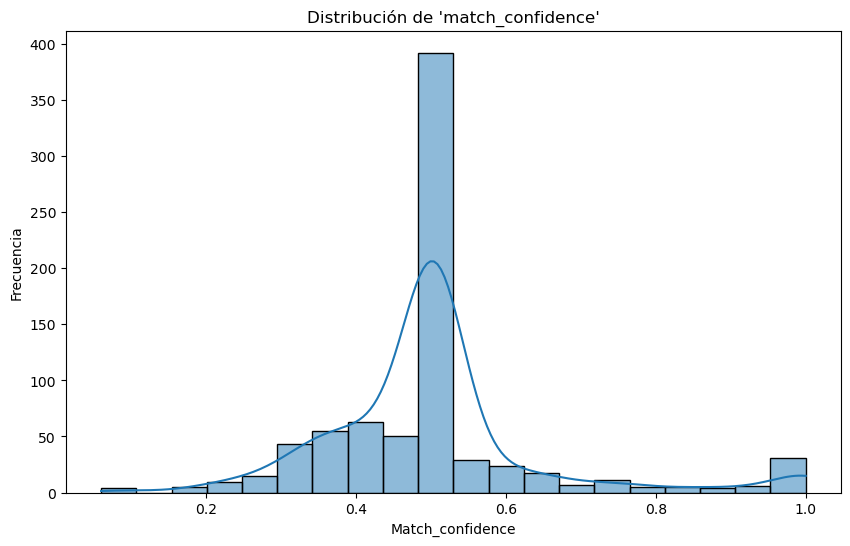

In [9]:
#Histograma para ver la distribución de match_ confidence
plt.figure(figsize=(10,6))
sns.histplot(df_pois["match_confidence"], bins=20,kde=True)
plt.title("Distribución de 'match_confidence'")
plt.xlabel("Match_confidence")
plt.ylabel("Frecuencia")
plt.show()

### 📊 Conclusión – Distribución de *match_confidence*

La distribución de la variable *match_confidence* muestra una alta concentración de valores en torno a rangos medios, especialmente cerca de 0.5, lo que indica que gran parte de las coincidencias presentan un nivel de confianza moderado.

Se observa, además, la presencia de valores extremos tanto bajos como altos, aunque en menor proporción. Esto sugiere que, si bien existen coincidencias muy fiables y otras poco consistentes, la mayoría de los casos se sitúan en una zona intermedia de incertidumbre.

Este comportamiento puede estar relacionado con la naturaleza del proceso de matching, donde no todas las asociaciones son completamente claras o directas. Por ello, esta variable resulta clave para etapas posteriores, ya que puede utilizarse como criterio de filtrado en el análisis y modelado.

En conjunto, la distribución refleja un equilibrio entre precisión y ambigüedad en las coincidencias, lo que aporta información relevante para la toma de decisiones dentro del proyecto.

---

## ***4.3 Distribución de las categorías***

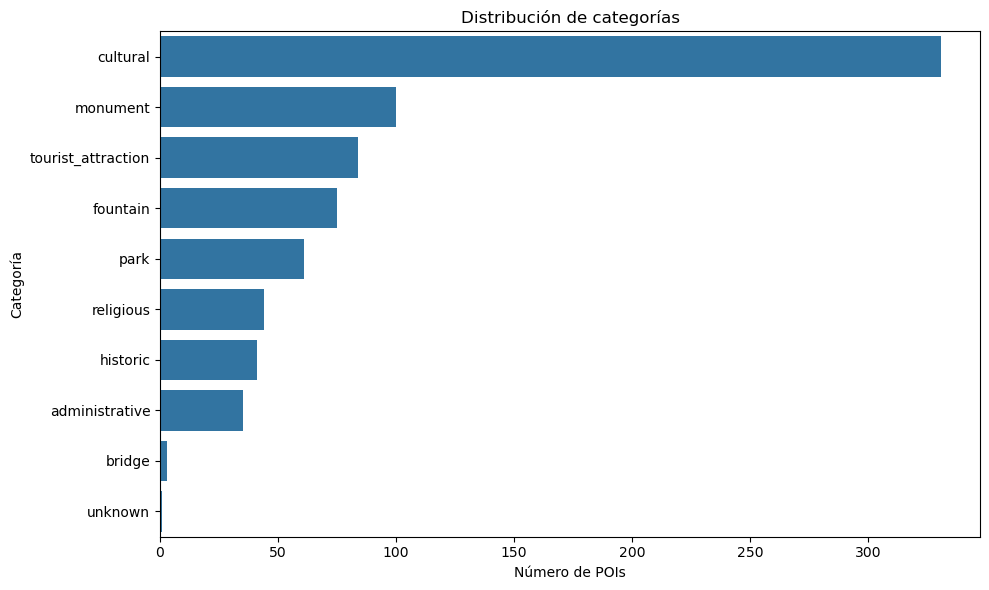

In [10]:
plt.figure(figsize=(10,6))

order = df_pois["category"].value_counts().index

sns.countplot(data=df_pois, y="category", order=order)
plt.title("Distribución de categorías")
plt.xlabel("Número de POIs")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

### 📊 Conclusión – Distribución de las categorías

El análisis de las categorías de los POIs revela una distribución claramente desequilibrada, con un predominio notable de la categoría *cultural*, seguida a cierta distancia por *monument* y *tourist_attraction*. Esto indica que el dataset está especialmente orientado hacia puntos de interés de carácter cultural y turístico.

Por otro lado, categorías como *park*, *religious* o *historic* presentan una representación intermedia, mientras que otras como *bridge* o *unknown* tienen una presencia prácticamente residual.

En conjunto, este análisis permite comprender mejor la composición del dataset y aporta contexto clave para el desarrollo del proyecto.

---

## ***4.4 Distribución de las subcategorías***

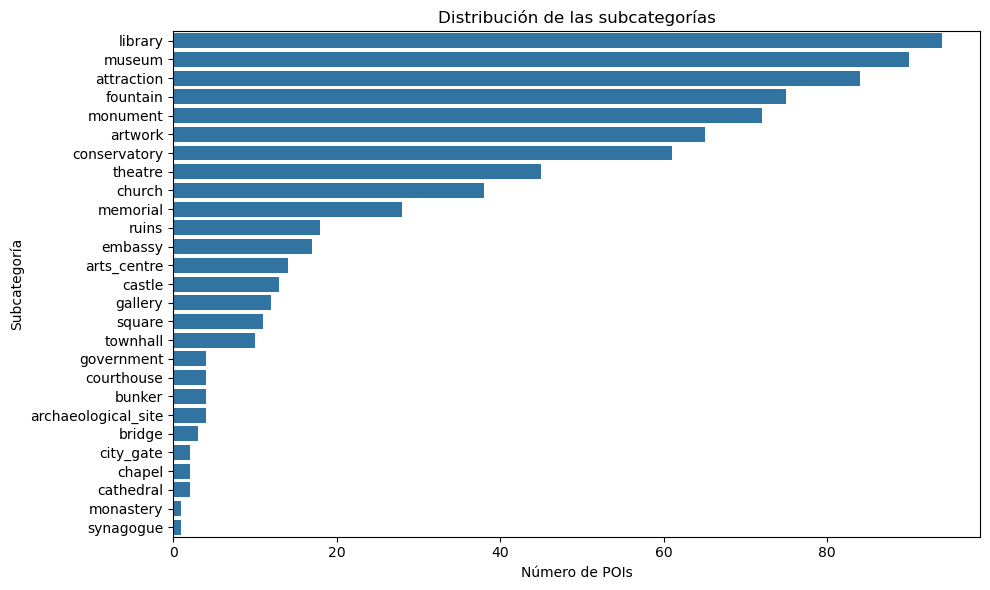

In [11]:
plt.figure(figsize=(10,6))

order = df_pois["subcategory"].value_counts().index

sns.countplot(data=df_pois, y="subcategory", order=order)
plt.title("Distribución de las subcategorías")
plt.xlabel("Número de POIs")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.show()

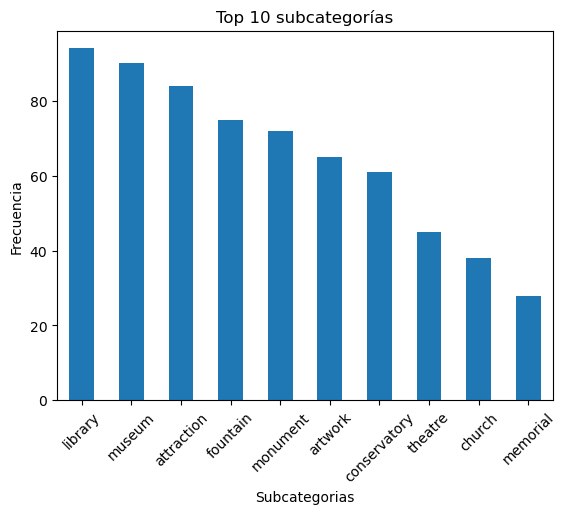

In [25]:
# Diagrama de barras para sacar las 10 subcategorias con más frecuencia
df_pois["subcategory"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 subcategorías")
plt.xticks(rotation=45)
plt.xlabel("Subcategorias")
plt.ylabel("Frecuencia")
plt.show()

### 📊 Conclusión – Distribución de las subcategorías

La distribución de las subcategorías muestra una alta concentración en unos pocos tipos de POIs, destacando principalmente *library*, *museum* y *attraction*. Esto refuerza la idea de que el dataset está fuertemente orientado hacia elementos culturales y turísticos específicos.

A medida que se desciende en frecuencia, se observa una larga cola de subcategorías con menor representación, como *chapel*, *monastery* o *synagogue*, lo que indica una mayor granularidad pero también una menor presencia de estos tipos en los datos.

Este patrón evidencia una distribución desigual, donde unas pocas subcategorías dominan el conjunto, mientras que muchas otras aparecen de forma residual. Desde el punto de vista analítico, esto puede influir en el rendimiento de modelos y en la capacidad de generalización, especialmente en aquellas clases con menor representación.

En conjunto, este análisis permite comprender con mayor detalle la composición interna de las subcategorías, aportando una visión más fina del tipo de POIs presentes en el dataset.

---

## ***4.5 Distribución geográfica de los POIs en toda la ciudad***

In [13]:

fig = px.scatter_map(
    df_pois,
    lat="latitude",
    lon="longitude",
    color="category", # Se puede cambiar a subcategory
    hover_name="name",
    hover_data={
        "subcategory": True,
        "rating": True,
        "match_confidence": True,
        "visit_duration": True,
        "is_likely_open": True,
        "is_24_7": True,
        "has_opening_hours": True,
        "score": True,
        "latitude": False,
        "longitude": False,
    },
    zoom=12,
    height=600,
    width=1000,
)

fig.update_layout(
    map_style="open-street-map",
    margin=dict(r=0, t=40, l=0, b=0),
    title="Mapa interactivo de POIs en Barcelona",
)

fig.show()

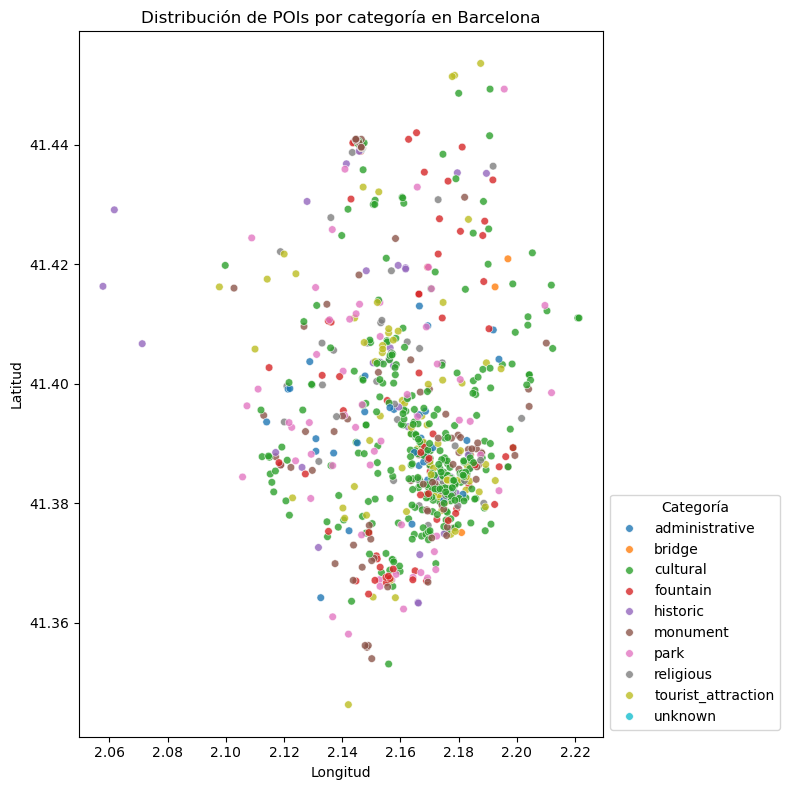

In [14]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=df_pois,
    x="longitude",
    y="latitude",
    hue="category",
    s=30,
    alpha=0.8
)

plt.title("Distribución de POIs por categoría en Barcelona")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.legend(title="Categoría", loc="lower left", bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.show()

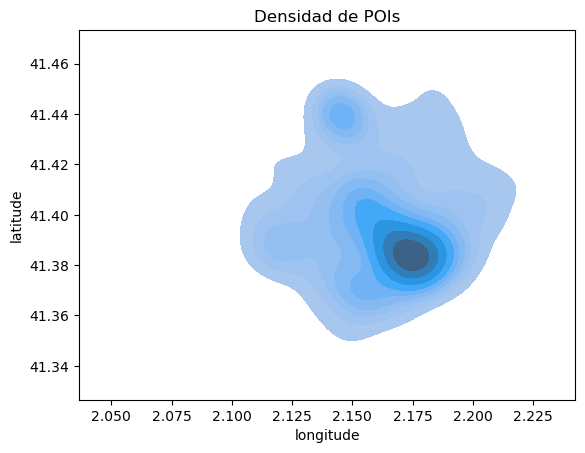

In [15]:
plt.figure()
sns.kdeplot(
    x=df_pois["longitude"],
    y=df_pois["latitude"],
    fill=True
)
plt.title("Densidad de POIs")
plt.show()

## ***4.6 Distribución de la puntuación (score)***

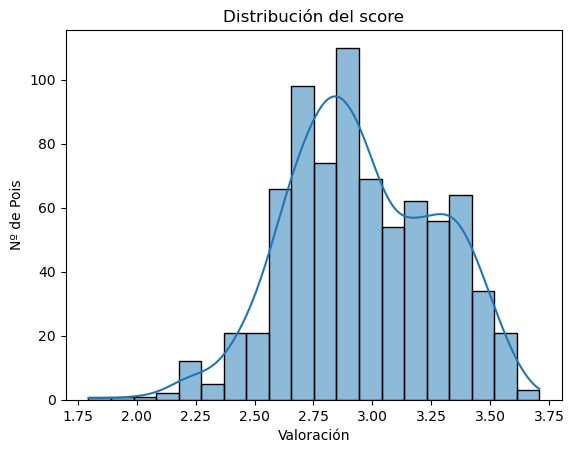

In [16]:
sns.histplot(df_pois["score"], bins=20,kde=True)
plt.title("Distribución del score")
plt.ylabel("Nº de Pois")
plt.xlabel("Valoración")
plt.show()

### 📊 Conclusión – Distribución de la puntuación (*score*)

La distribución del *score* presenta una concentración en valores intermedios, principalmente entre 2.5 y 3.3, lo que indica que la mayoría de los POIs se sitúan en un rango de valoración moderado.

A diferencia del *rating*, no se observa una acumulación en los valores más altos, sino una distribución más equilibrada alrededor de la media. Esto sugiere que esta métrica podría estar capturando una evaluación más diferenciada o estricta de los POIs.

Asimismo, la forma de la distribución, relativamente simétrica, indica una menor presencia de sesgos extremos, aunque siguen existiendo algunos valores atípicos en los extremos.

En conjunto, el *score* aporta una perspectiva complementaria al *rating*, proporcionando una medida más balanceada que puede resultar especialmente útil en tareas de modelado dentro del proyecto.

----

## ***4.7 Distribución de la duración estimada de visita***

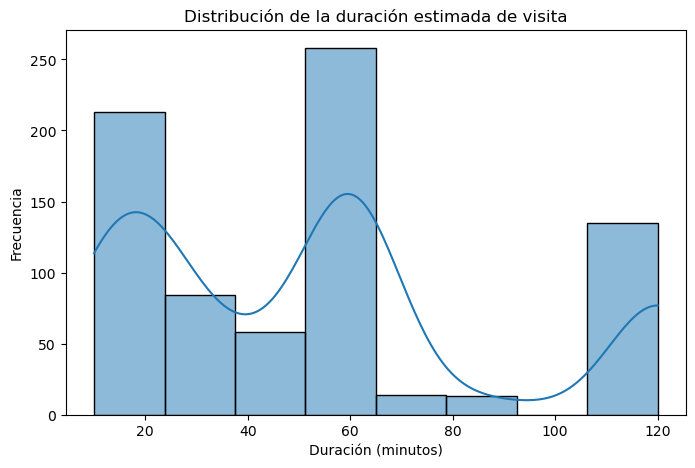

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df_pois["visit_duration"], bins=8, kde=True)
plt.title("Distribución de la duración estimada de visita")
plt.xlabel("Duración (minutos)")
plt.ylabel("Frecuencia")
plt.show()

### 📊 Conclusión – Distribución de la duración estimada de visita

La distribución de la duración estimada de visita muestra una mayor concentración en valores intermedios, especialmente en torno a los 60 minutos, lo que sugiere que la mayoría de los POIs requieren aproximadamente una hora de visita.

Asimismo, se observan otros grupos relevantes en duraciones más cortas (alrededor de 15–30 minutos) y más largas (cercanas a 120 minutos), lo que indica la existencia de distintos tipos de experiencias según el tipo de punto de interés.

Esta variabilidad refleja la heterogeneidad del dataset, donde coexisten POIs de visita rápida con otros que implican una mayor dedicación de tiempo. 

En conjunto, esta variable aporta información útil para posibles aplicaciones prácticas, como la planificación de rutas o sistemas de recomendación, donde la duración estimada puede ser un factor clave en la toma de decisiones.

---

## ***4.8 Distribución del tipo de visita esperada***

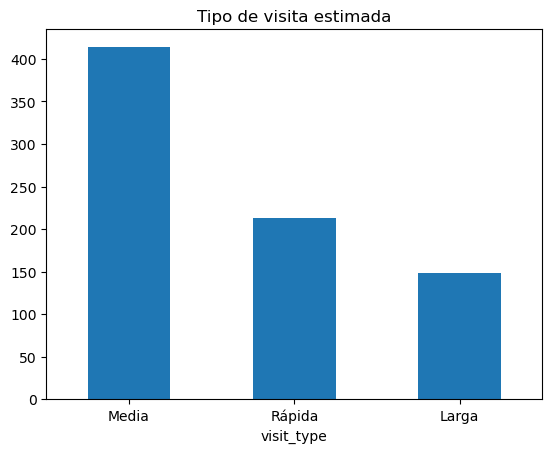

In [42]:
df_pois["visit_type"] = df_pois["visit_duration"].apply(
    lambda x: "Rápida" if x <= 20 else ("Larga" if x >= 90 else "Media")
)

df_pois["visit_type"].value_counts().plot(kind="bar")
plt.title("Tipo de visita estimada")
plt.xticks(rotation=0)
plt.show()

### 📊 Conclusión – Tipo de visita estimada

La categorización del tiempo de visita en *rápida*, *media* y *larga* permite observar que predominan claramente las visitas de duración media, lo que indica que la mayoría de los POIs requieren un tiempo moderado de dedicación.

Las visitas rápidas también presentan una presencia relevante, reflejando la existencia de puntos de interés que pueden ser explorados en poco tiempo. Por el contrario, las visitas largas son menos frecuentes, lo que sugiere que los POIs que requieren una mayor inversión de tiempo son más específicos o menos comunes.

Esta distribución refuerza la idea de que el dataset está compuesto principalmente por experiencias accesibles en términos de tiempo, lo cual puede ser especialmente útil en aplicaciones orientadas a la planificación de itinerarios.

En conjunto, esta variable aporta una representación más interpretable de la duración de visita, facilitando su uso en análisis posteriores y en posibles sistemas de recomendación.

---

## ***4.9 Distribución la probabilidad de apertura de los POIs***

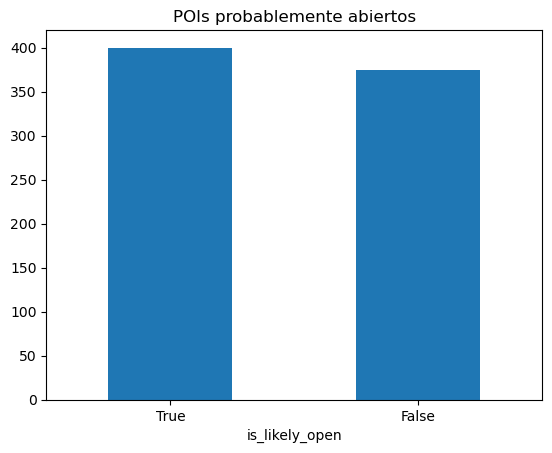

In [34]:
df_pois["is_likely_open"].value_counts().plot(kind="bar")
plt.title("POIs probablemente abiertos")
plt.xticks(rotation=0)
plt.show()

### 📊 Conclusión – Probabilidad de apertura de los POIs

El análisis de la variable *is_likely_open* muestra una distribución relativamente equilibrada entre los POIs clasificados como probablemente abiertos y aquellos que no lo están. No obstante, se observa una ligera predominancia de los casos positivos.

Este comportamiento sugiere que, en general, una parte importante de los puntos de interés presenta condiciones favorables de apertura, aunque existe también una proporción significativa de incertidumbre o posible cierre.

Desde una perspectiva analítica, esta variable resulta especialmente relevante en aplicaciones prácticas, ya que puede influir directamente en la experiencia del usuario, por ejemplo, en sistemas de recomendación o planificación de visitas.

En conjunto, la distribución refleja un escenario realista donde no todos los POIs garantizan disponibilidad, lo que refuerza la importancia de incorporar esta información en etapas posteriores del proyecto.

---

## ***4.10 Distribución de la disponibilidad de horarios***

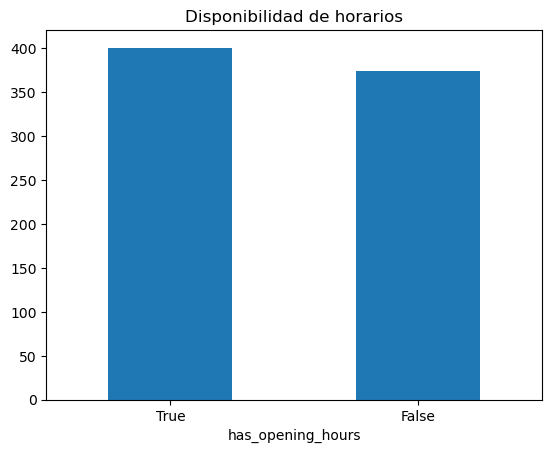

In [36]:
df_pois["has_opening_hours"].value_counts().plot(kind="bar")
plt.title("Disponibilidad de horarios")
plt.xticks(rotation=0)
plt.show()

### 📊 Conclusión – Disponibilidad de horarios

La variable *has_opening_hours* presenta una distribución bastante equilibrada, con una ligera mayoría de POIs que sí disponen de información de horarios. Esto indica que una parte significativa del dataset cuenta con datos estructurados sobre la disponibilidad temporal de los puntos de interés.

Sin embargo, la presencia considerable de POIs sin esta información sugiere cierta incompletitud en los datos, lo que puede afectar a la calidad de análisis posteriores o a aplicaciones prácticas como la planificación de visitas.

Desde una perspectiva aplicada, esta variable resulta especialmente relevante, ya que la disponibilidad de horarios es un factor clave en la experiencia del usuario. Por ello, podría ser necesario considerar estrategias de imputación o filtrado en fases posteriores del proyecto.

En conjunto, este análisis pone de manifiesto tanto el valor como las limitaciones de esta variable dentro del dataset.

---

## ***4.11 Distribución del número de tags por POI***

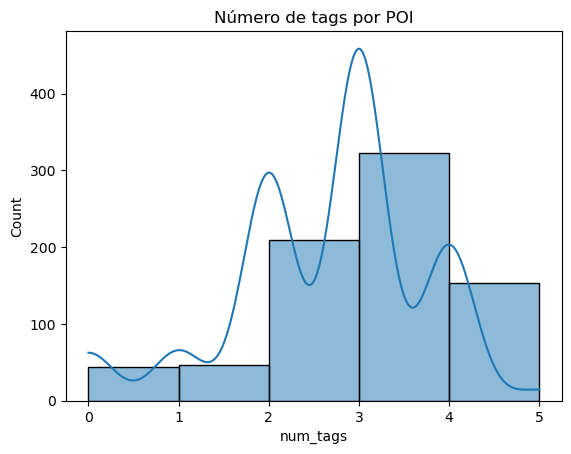

In [37]:
df_pois["num_tags"] = df_pois["tags"].apply(len)
sns.histplot(df_pois["num_tags"], bins=5,kde=True)
plt.title("Número de tags por POI")
plt.show()

### 📊 Conclusión – Número de tags por POI

La distribución del número de *tags* por POI muestra una clara concentración en valores intermedios, principalmente entre 2 y 4 etiquetas por elemento. Esto indica que la mayoría de los puntos de interés están descritos con un nivel moderado de detalle.

La presencia de POIs con pocos o ningún *tag* es reducida, lo que sugiere que, en general, el dataset cuenta con un buen nivel de enriquecimiento semántico. Asimismo, los casos con un mayor número de etiquetas son menos frecuentes, reflejando que un alto grado de descripción no es la norma.

Desde una perspectiva analítica, esta variable resulta relevante, ya que los *tags* pueden utilizarse para tareas de clasificación, recomendación o clustering, aportando información contextual adicional sobre los POIs.

En conjunto, la distribución observada indica un equilibrio adecuado entre simplicidad y riqueza descriptiva en los datos.

---

# ***5. Distribuciones avanzadas entre columnas***

## ***5.1 Rating por categoría***

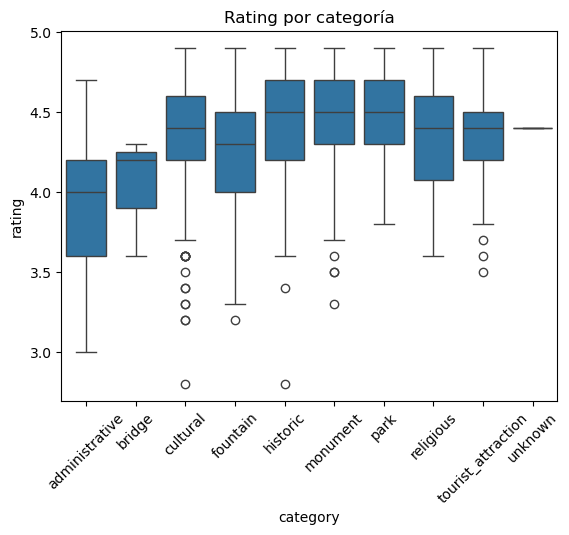

In [17]:
sns.boxplot(x="category", y="rating", data=df_pois)
plt.xticks(rotation=45)
plt.title("Rating por categoría")
plt.show()

### 📌 Análisis y justificación de los *outliers* en **Rating por categoría**

En el boxplot de **rating por categoría** se observan varios puntos aislados por debajo de la caja (principalmente entre **3.0 y 3.7**), que estadísticamente aparecen como *outliers* según el criterio del rango intercuartílico (IQR). Es importante destacar que, en este contexto, estos valores **no necesariamente representan errores**, sino casos menos frecuentes dentro de cada categoría.

#### 🔎 ¿Por qué aparecen *outliers* en rating?
1. **Naturaleza subjetiva del rating:** la valoración es una variable basada en opiniones de usuarios, por lo que es normal que existan POIs con puntuaciones significativamente más bajas que la mayoría.
2. **Efecto “cola” típico en ratings:** en datasets de reseñas suele existir una concentración fuerte en valores altos (4–5) y una minoría con valoraciones bajas que queda marcada como *outlier*.
3. **Heterogeneidad dentro de una misma categoría:** una categoría como *cultural* o *historic* puede agrupar POIs muy distintos (desde un museo importante hasta un punto menor), lo que genera dispersión y valores extremos.

#### 🧠 Interpretación por categoría (según lo observado en el gráfico)
- **Cultural / Historic / Monument:** presentan varios *outliers* bajos. Esto puede indicar que, aunque la mayoría de POIs de estas categorías están bien valorados, existe un subconjunto de lugares con menor atractivo, mantenimiento o experiencia percibida.
- **Fountain / Tourist_attraction:** también muestran algunos valores bajos aislados, coherentes con que algunos puntos pueden ser menos accesibles, menos relevantes o estar peor conservados, a pesar de pertenecer a categorías generalmente populares.
- **Administrative / Bridge:** aparecen con menos *outliers* visibles, probablemente por menor número de observaciones o por una distribución más concentrada.
- **Unknown:** apenas muestra variabilidad (prácticamente una línea), lo que sugiere pocas observaciones o valores muy homogéneos en esa categoría, por lo que no aporta evidencia clara sobre outliers.

#### ✅ Decisión tomada
No se eliminarán estos *outliers* porque:
- **Son valores plausibles y reales**, no incoherencias numéricas (siguen estando dentro del rango lógico 0–5).
- Aportan información relevante: permiten identificar POIs potencialmente menos recomendables, lo cual es útil para el sistema de recomendación.
- En un contexto de rutas, estos valores ayudan a que el modelo pueda **priorizar POIs mejor valorados** y penalizar aquellos con peor experiencia percibida.

En conclusión, los *outliers* observados reflejan variabilidad real en la percepción de los usuarios y se consideran parte informativa del dataset, no errores de limpieza.

---

## ***5.2 Tiempo de visita por categoría***

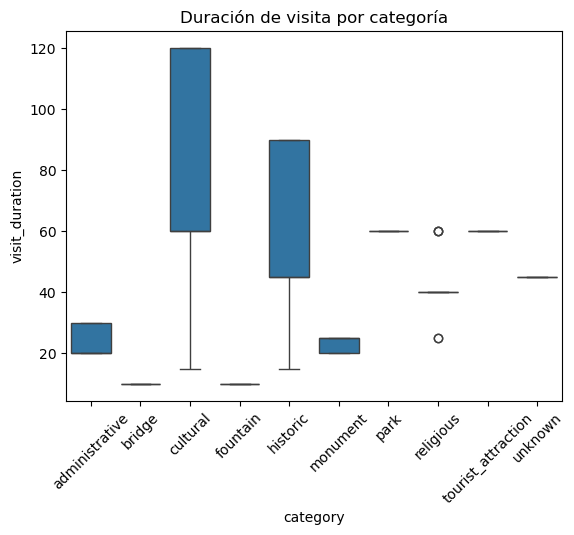

In [18]:
sns.boxplot(x="category", y="visit_duration", data=df_pois)
plt.xticks(rotation=45)
plt.title("Duración de visita por categoría")
plt.show()

### 📌 Análisis y justificación de los *outliers* en **Duración de visita por categoría**

El boxplot de **visit_duration por categoría** muestra una mayor dispersión que en el caso del rating, con presencia de valores que aparecen como *outliers* según el criterio del rango intercuartílico (IQR). Sin embargo, estos valores no representan errores, sino diferencias al tipo de experiencia que ofrece cada punto de interés.

#### 🔎 ¿Por qué aparecen *outliers* en la duración?

1. **Naturaleza heterogénea de las categorías:**  
   Una misma categoría puede incluir POIs con experiencias muy distintas. Por ejemplo, dentro de *cultural* o *historic* conviven desde visitas rápidas hasta experiencias más extensas como museos o complejos históricos.

2. **Asignación basada en subcategorías:**  
   La variable `visit_duration` se ha construido a partir de la subcategoría, lo que introduce variabilidad dentro de una misma categoría principal. Esto genera distribuciones más amplias y valores extremos dentro de cada grupo.

3. **Diferencias reales en el tiempo de visita:**  
   No todos los POIs requieren el mismo tiempo:
   - Elementos como **fuentes, puentes o monumentos** suelen implicar visitas cortas (10–25 minutos).
   - Lugares como **museos o centros culturales** pueden requerir hasta 90–120 minutos.

---

#### 🧠 Interpretación por categoría

- **Cultural:** presenta la mayor dispersión (aprox. 60–120 min), lo cual es coherente con la diversidad de espacios culturales (bibliotecas, museos, centros artísticos).
- **Historic:** muestra una distribución amplia (45–90 min), reflejando distintos niveles de profundidad en la visita.
- **Religious:** aparecen valores más bajos (~25 min) junto a otros más altos (~60 min), lo que indica variabilidad entre iglesias pequeñas y catedrales más complejas.
- **Administrative / Bridge / Fountain:** tienen valores muy concentrados y bajos, representando visitas rápidas y homogéneas.
- **Park / Tourist_attraction:** presentan valores más estables (alrededor de 60 min), lo que indica una experiencia más uniforme.
- **Unknown:** muestra valores intermedios, posiblemente debido a una asignación por defecto.

---

#### ⚠️ Sobre los *outliers*

Los puntos que aparecen como *outliers* no deben interpretarse como errores, ya que:

- Se encuentran dentro de rangos lógicos (10–120 minutos).
- Representan correctamente la variabilidad de experiencias reales.
- Son consecuencia directa del diseño de la variable basada en subcategorías.

---

#### ✅ Decisión tomada

No se eliminan los *outliers* porque:

- Aportan información clave para la planificación de rutas.
- Permiten diferenciar entre visitas rápidas y experiencias más completas.
- Son fundamentales para optimizar recomendaciones en función del tiempo disponible del usuario.

---

### 🧠 Conclusión

La variable `visit_duration` presenta una distribución coherente y realista, donde la variabilidad observada refleja diferencias naturales entre tipos de POIs. Estos valores extremos no solo son válidos, sino que resultan esenciales para el correcto funcionamiento del sistema de recomendación basado en tiempo.

---

## ***5.3 Rating en base a la duración de la visita***

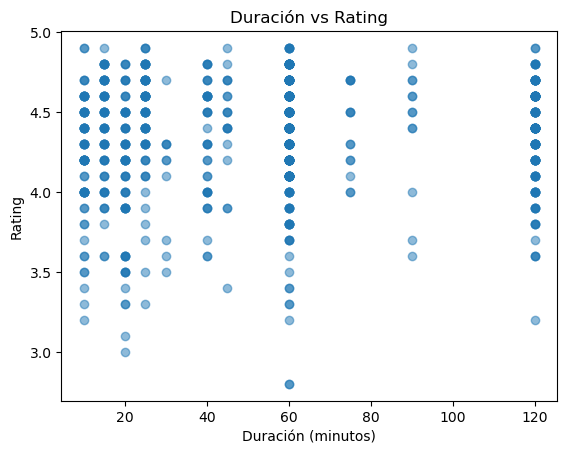

In [32]:
plt.scatter(df_pois["visit_duration"], df_pois["rating"], alpha=0.5)
plt.xlabel("Duración (minutos)")
plt.ylabel("Rating")
plt.title("Duración vs Rating")
plt.show()

### 📌 Análisis de la relación entre duración de la visita y rating

El diagrama de dispersión entre *visit_duration* y *rating* permite explorar si existe una relación directa entre el tiempo estimado de visita de un POI y la valoración que recibe por parte de los usuarios.

A nivel general, no se observa una relación lineal clara entre ambas variables. Los *ratings* se mantienen en valores relativamente altos (principalmente entre 4.0 y 4.8) a lo largo de prácticamente todos los rangos de duración, desde visitas cortas hasta experiencias más largas.

---

### 🔍 ¿Qué patrones se observan?

1. **Alta concentración de ratings elevados:**
   - Independientemente de la duración, la mayoría de los POIs presentan valoraciones altas.
   - Esto refuerza el sesgo positivo ya identificado previamente en la variable *rating*.

2. **Ausencia de correlación evidente:**
   - No se aprecia que visitas más largas impliquen mejores valoraciones.
   - Tampoco las visitas cortas presentan sistemáticamente peores resultados.

3. **Mayor dispersión en duraciones intermedias:**
   - En rangos como 30–60 minutos se observa una mayor variabilidad en los ratings.
   - Esto puede deberse a la diversidad de tipos de POIs incluidos en ese intervalo.

4. **Valores atípicos:**
   - Existen algunos casos con ratings más bajos (≈3.0–3.5) distribuidos en distintas duraciones, sin un patrón claro.

---

### 🧠 Interpretación

La duración de la visita no parece ser un factor determinante en la valoración de los POIs. Es probable que el *rating* esté más influenciado por otros aspectos como la calidad de la experiencia, el interés cultural o el estado de conservación del lugar.

Además, el hecho de que los ratings sean consistentemente altos sugiere que esta variable puede tener una capacidad limitada para discriminar entre distintos tipos de POIs en términos de calidad percibida.

---

### ⚠️ Implicaciones para el modelo

- La variable *visit_duration* no parece ser un buen predictor directo del *rating*.
- Puede resultar más útil en combinación con otras variables (categoría, subcategoría, tags).
- Es especialmente relevante para tareas de planificación y recomendación, más que para predicción de valoraciones.

---

### ✅ Conclusión

No existe una relación clara entre la duración estimada de visita y la valoración de los POIs. Ambas variables aportan información complementaria: mientras que el *rating* refleja la percepción del usuario, la duración está más relacionada con el tipo de experiencia ofrecida.

---

## ***5.4 Rating en base a la puntuación del POI (score)***

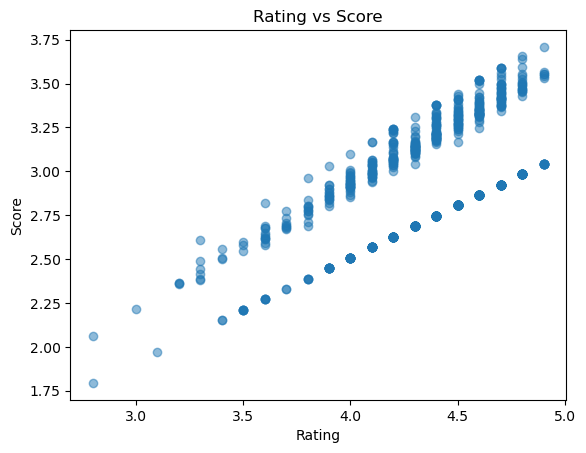

In [19]:
plt.scatter(df_pois["rating"], df_pois["score"], alpha=0.5)
plt.xlabel("Rating")
plt.ylabel("Score")
plt.title("Rating vs Score")
plt.show()

### 📌 Análisis de la relación entre *rating* y *score*

El gráfico de dispersión entre *rating* y *score* muestra una relación clara y positiva entre ambas variables, indicando que, a medida que aumenta la valoración de los usuarios, también lo hace la puntuación asociada al POI.

A diferencia de otros análisis anteriores, en este caso sí se observa un patrón estructurado, lo que sugiere que ambas métricas están fuertemente relacionadas.

---

### 🔍 ¿Qué patrones se observan?

1. **Relación positiva evidente:**
   - Existe una tendencia creciente bien definida.
   - Los valores de *score* aumentan de forma consistente con el incremento del *rating*.

2. **Estructura en bandas:**
   - Se observan líneas o agrupaciones diagonales, lo que sugiere que el *score* puede estar calculado a partir del *rating* mediante algún tipo de transformación o discretización.

3. **Baja dispersión relativa:**
   - Para un mismo valor de *rating*, el *score* no varía de forma extrema.
   - Esto indica coherencia entre ambas variables.

4. **Presencia de algunos valores diferenciados:**
   - Aunque la relación es clara, existen ligeras variaciones dentro de cada nivel de *rating*, lo que aporta cierto grado de variabilidad.

---

### 🧠 Interpretación

El *score* parece ser una variable derivada o altamente influenciada por el *rating*, lo que explica la fuerte correlación observada. Es posible que el *score* incorpore ajustes adicionales (normalización, ponderación u otras variables), pero manteniendo como base la valoración de los usuarios.

Este comportamiento indica que ambas variables contienen información similar, aunque no necesariamente redundante en su totalidad.

---

### ⚠️ Implicaciones para el modelo

- Existe riesgo de multicolinealidad si ambas variables se utilizan simultáneamente en modelos predictivos.
- Puede ser recomendable:
  - Seleccionar solo una de las dos variables, o
  - Analizar en mayor profundidad cómo se construye el *score*.

- El *score* puede ser útil como versión más suavizada o procesada del *rating*.

---

### ✅ Conclusión

El *rating* y el *score* presentan una relación directa y consistente, lo que sugiere que ambas variables capturan una misma dimensión de calidad percibida. No obstante, su uso conjunto debe evaluarse cuidadosamente en fases posteriores para evitar redundancias en el modelado.

---

## ***5.5 Puntuación en base a la confianza de match (match_confidence)***

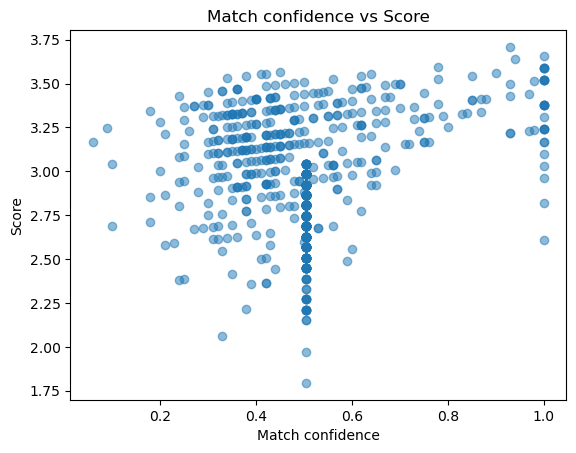

In [20]:
plt.scatter(df_pois["match_confidence"], df_pois["score"], alpha=0.5)
plt.xlabel("Match confidence")
plt.ylabel("Score")
plt.title("Match confidence vs Score")
plt.show()

### 📌 Análisis de la relación entre *match_confidence* y *score*

El gráfico de dispersión entre *match_confidence* y *score* permite analizar si el nivel de confianza en el proceso de matching influye en la puntuación final de los POIs.

A diferencia de la relación observada entre *rating* y *score*, en este caso no se aprecia una correlación clara ni una tendencia definida entre ambas variables.

---

### 🔍 ¿Qué patrones se observan?

1. **Alta dispersión de los datos:**
   - Para valores similares de *match_confidence*, el *score* presenta una variabilidad considerable.
   - Esto indica que la confianza del matching no determina directamente la puntuación.

2. **Concentración en valores medios:**
   - La mayoría de los puntos se agrupan en niveles de *match_confidence* entre 0.3 y 0.6.
   - En este rango, los *scores* se mantienen mayoritariamente entre 2.8 y 3.4.

3. **Presencia de estructuras verticales:**
   - Se observan agrupaciones verticales (especialmente alrededor de 0.5), lo que sugiere posibles valores discretizados o asignaciones frecuentes en el proceso de matching.

4. **Valores altos de confianza:**
   - En niveles cercanos a 1.0, los *scores* tienden a ser ligeramente más altos, aunque sin una relación suficientemente fuerte como para considerarse determinante.

---

### 🧠 Interpretación

El *match_confidence* parece reflejar la calidad o seguridad del proceso de vinculación de datos, pero no tiene un impacto directo sobre la valoración o puntuación del POI. Es decir, un buen matching no implica necesariamente una mejor puntuación del lugar.

Esto sugiere que ambas variables capturan dimensiones distintas: mientras que el *score* está relacionado con la calidad percibida, el *match_confidence* está vinculado a la fiabilidad del proceso de integración de datos.

---

### ⚠️ Implicaciones para el modelo

- *match_confidence* no es un predictor fuerte del *score* por sí solo.
- Puede ser más útil como variable de control o filtrado (por ejemplo, priorizar matches de alta confianza).
- Su uso es relevante para asegurar la calidad del dataset más que para modelar la puntuación.

---

### ✅ Conclusión

No existe una relación clara entre la confianza del matching y la puntuación de los POIs. Ambas variables aportan información complementaria: una sobre la calidad del dato y otra sobre la calidad percibida del punto de interés.

---

## ***5.6 Matriz de correlación entre variables***

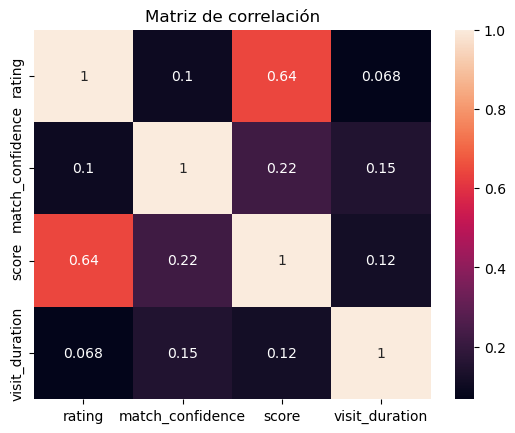

In [23]:
corr = df_pois[["rating", "match_confidence", "score", "visit_duration"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

### 📌 Análisis de la matriz de correlación

La matriz de correlación permite evaluar la relación lineal entre las principales variables numéricas del dataset: *rating*, *score*, *match_confidence* y *visit_duration*.

En general, los valores observados indican correlaciones bajas o moderadas, lo que sugiere que la mayoría de las variables capturan información complementaria.

---

### 🔍 ¿Qué relaciones destacan?

1. **Relación moderada entre *rating* y *score* (≈ 0.64):**
   - Es la correlación más alta observada.
   - Confirma que ambas variables están relacionadas y miden una dimensión similar de calidad percibida.

2. **Relaciones débiles con *match_confidence*:**
   - Presenta correlaciones bajas con el resto de variables (≈ 0.10–0.22).
   - Indica que esta variable es relativamente independiente.

3. **Baja correlación de *visit_duration*:**
   - Muestra valores muy bajos con todas las variables (≈ 0.06–0.15).
   - Refuerza la idea de que la duración de la visita no está directamente relacionada con la valoración o el score.

4. **Ausencia de correlaciones fuertes adicionales:**
   - No se identifican relaciones lineales relevantes más allá de *rating–score*.

---

### 🧠 Interpretación

El análisis confirma que la mayoría de las variables aportan información distinta dentro del dataset. En particular:

- *rating* y *score* están alineadas conceptualmente.
- *match_confidence* refleja la calidad del matching, no la calidad del POI.
- *visit_duration* describe el tipo de experiencia, sin influir directamente en la valoración.

---

### ⚠️ Implicaciones para el modelo

- Posible redundancia entre *rating* y *score* → evaluar selección de variables.
- Baja multicolinealidad en general → favorable para modelos predictivos.
- Variables como *visit_duration* y *match_confidence* pueden aportar valor en combinación con otras.

---

### ✅ Conclusión

La matriz de correlación muestra un dataset equilibrado, donde la mayoría de variables son complementarias. La única relación destacada es entre *rating* y *score*, mientras que el resto de variables aportan información independiente, lo que resulta positivo para fases posteriores de modelado.